## Re-evaluate Models with ROC-AUC, Tabular Display, and Visualization

This section consolidates the data loading, preprocessing, model re-training, evaluation, and visualization steps to ensure all necessary variables are in scope and to include ROC-AUC as a key performance metric for our binary classification models.

--- Loading and Preprocessing Data ---
Data loading and preprocessing complete.

--- Re-training Models for Evaluation ---
Logistic Regression model re-trained.
Decision Tree Classifier model re-trained.
Random Forest Classifier model re-trained.
XGBoost Classifier model re-trained.
K-Nearest Neighbors Classifier model re-trained with algorithm='brute'.

--- Evaluating Models on Validation Data ---
Logistic Regression evaluated.
Decision Tree evaluated.
Random Forest evaluated.
XGBoost evaluated.
K-Nearest Neighbors evaluated.

--- Model Performance on Validation Data ---
| Model               |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| Logistic Regression |   1        |    1        | 1        |   1        |  1        |
| Decision Tree       |   1        |    1        | 1        |   1        |  1        |
| Random Forest       |   1        |    1        | 1        |   1        

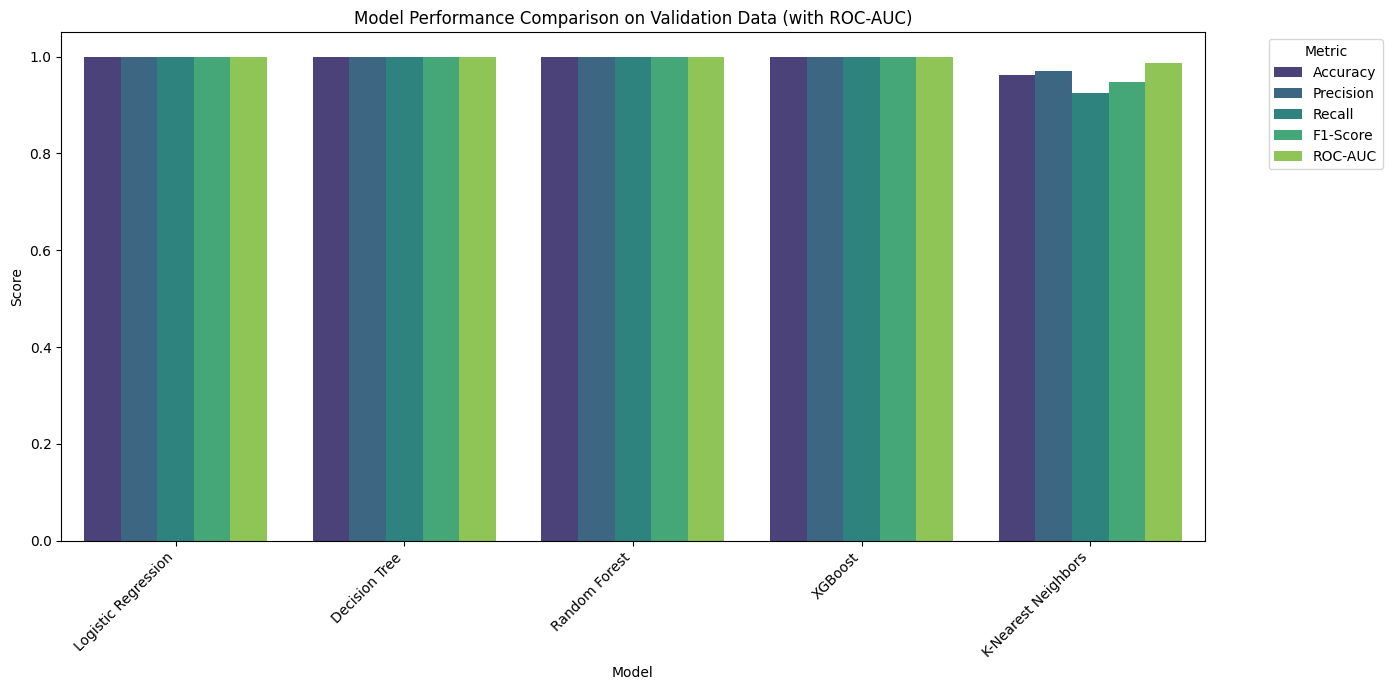

In [ ]:
!pip install tabulate
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- 1. Load and Preprocess Data ---
print('--- Loading and Preprocessing Data ---')

# Load the training dataset
df_train = pd.read_csv('Train.csv')

# Splitting into features and label
X_train = df_train.drop("is_canceled", axis=1)  # label column
y_train = df_train["is_canceled"]

# Load the validation dataset
df_validation = pd.read_csv('Validation.csv')

X_validation = df_validation.drop("is_canceled", axis=1)
y_validation = df_validation["is_canceled"]

# Identify categorical and numerical columns from training data
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns
numerical_cols = X_train.select_dtypes(include=np.number).columns

# Create and fit the ColumnTransformer on training data
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ("scale", StandardScaler(), numerical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_validation_processed = preprocessor.transform(X_validation)

y_train = y_train.to_numpy()
y_validation = y_validation.to_numpy()

print("Data loading and preprocessing complete.")

# --- 2. Re-initialize and Re-train Base Models ---
print('\n--- Re-training Models for Evaluation ---')

# Logistic Regression
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_processed, y_train)
print("Logistic Regression model re-trained.")

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_split=2, min_samples_leaf=1)
dt_model.fit(X_train_processed, y_train)
print("Decision Tree Classifier model re-trained.")

# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_processed, y_train)
print("Random Forest Classifier model re-trained.")

# XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)
print("XGBoost Classifier model re-trained.")

# K-Nearest Neighbors Classifier
knn_model = KNeighborsClassifier(n_neighbors=5, algorithm='brute')
knn_model.fit(X_train_processed, y_train)
print("K-Nearest Neighbors Classifier model re-trained with algorithm='brute'.")

# --- 3. Evaluate Models and Collect Metrics ---
model_names = []
accuracies = []
precisions = []
recalls = []
f1_scores = []
roc_aucs = []

models = {
    "Logistic Regression": log_reg_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "K-Nearest Neighbors": knn_model
}

print('\n--- Evaluating Models on Validation Data ---')

for name, model in models.items():
    y_pred = model.predict(X_validation_processed)
    y_prob = model.predict_proba(X_validation_processed)[:, 1] # Get probabilities for ROC-AUC

    accuracy = accuracy_score(y_validation, y_pred)
    precision = precision_score(y_validation, y_pred, zero_division=0)
    recall = recall_score(y_validation, y_pred, zero_division=0)
    f1 = f1_score(y_validation, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_validation, y_prob)

    model_names.append(name)
    accuracies.append(accuracy)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)
    roc_aucs.append(roc_auc)

    print(f"{name} evaluated.")

# Create a DataFrame for results
results_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1-Score': f1_scores,
    'ROC-AUC': roc_aucs
})

print('\n--- Model Performance on Validation Data ---')
print(results_df.to_markdown(index=False))

# --- 4. Visualize Model Comparison ---
# Melt the DataFrame for plotting
df_melted = results_df.melt(
    id_vars=['Model'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    var_name='Metric',
    value_name='Value'
)

# Create the bar chart
plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_melted,
    x='Model',
    y='Value',
    hue='Metric',
    palette='viridis'
)
plt.title('Model Performance Comparison on Validation Data (with ROC-AUC)')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Set y-axis limit for better comparison
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they overlap
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()